In [1]:
import numpy as np
import matplotlib.pyplot as plt


In [2]:
# Endpoint energy in eV
E0 = 18600  

# Energy array: last 30 eV before endpoint
E = np.linspace(E0 - 30, E0, 1000)


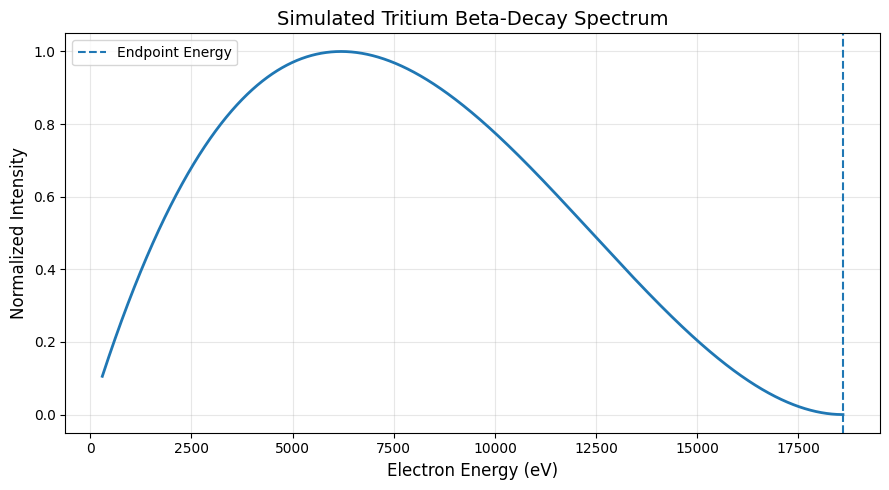

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================
# Parameters
# ============================================

E0 = 18600   # Tritium endpoint energy (eV)

# START FROM 300 eV INSTEAD OF 0
E = np.linspace(300, E0, 5000)

# ============================================
# Simplified Beta Spectrum
# ============================================

def beta_spectrum(E, E0):

    delta = E0 - E

    spectrum = E * (delta**2)

    spectrum = np.clip(spectrum, 0, None)

    return spectrum

# ============================================
# Generate Spectrum
# ============================================

spectrum = beta_spectrum(E, E0)

# NORMALIZE
spectrum = spectrum / np.max(spectrum)

# ============================================
# Plot
# ============================================

plt.figure(figsize=(9,5))

plt.plot(
    E,
    spectrum,
    lw=2
)

# Endpoint marker
plt.axvline(
    E0,
    linestyle='--',
    label='Endpoint Energy'
)

# ============================================
# Labels
# ============================================

plt.xlabel(
    "Electron Energy (eV)",
    fontsize=12
)

plt.ylabel(
    "Normalized Intensity",
    fontsize=12
)

plt.title(
    "Simulated Tritium Beta-Decay Spectrum",
    fontsize=14
)

plt.grid(True, alpha=0.3)

plt.legend()

plt.tight_layout()
plt.savefig(
    "Fig_4_1_Endpoint_Zoom.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [3]:
def beta_spectrum(E, E0, m2):
    epsilon = E0 - E
    
    spectrum = np.zeros_like(E)
    
    # Only valid when epsilon^2 > m2
    mask = epsilon**2 > m2
    
    spectrum[mask] = epsilon[mask] * np.sqrt(epsilon[mask]**2 - m2)
    
    return spectrum


In [4]:
m2_onm2_zero = 0.0
m2_one = 1.0

spectrum_zero = beta_spectrum(E, E0, m2_zero)
spectrum_one = beta_spectrum(E, E0, e)


NameError: name 'm2_zero' is not defined

In [5]:
plt.figure(figsize=(8,5))

plt.plot(E, spectrum_zero, label="m² = 0 eV²")
plt.plot(E, spectrum_one, label="m² = 1 eV²")

plt.xlabel("Electron Energy (eV)")
plt.ylabel("Arbitrary Spectrum Units")
plt.title("Beta Spectrum Near Endpoint")

plt.legend()
plt.grid(True)

plt.show()


NameError: name 'spectrum_zero' is not defined

<Figure size 800x500 with 0 Axes>

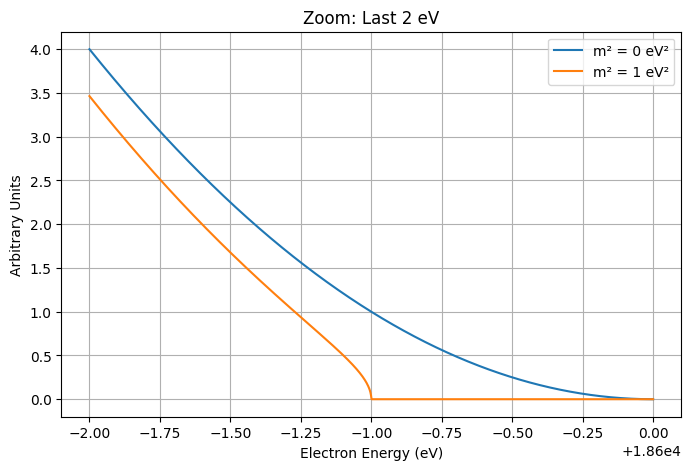

In [6]:
# Zoom into last 2 eV
E_zoom = np.linspace(E0 - 2, E0, 1000)

spectrum_zero_zoom = beta_spectrum(E_zoom, E0, 0.0)
spectrum_one_zoom = beta_spectrum(E_zoom, E0, 1.0)

plt.figure(figsize=(8,5))

plt.plot(E_zoom, spectrum_zero_zoom, label="m² = 0 eV²")
plt.plot(E_zoom, spectrum_one_zoom, label="m² = 1 eV²")

plt.xlabel("Electron Energy (eV)")
plt.ylabel("Arbitrary Units")
plt.title("Zoom: Last 2 eV")

plt.legend()
plt.grid(True)
plt.savefig(
    "Fig_4_1_Endpoint_Zoom.png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()


In [7]:
def integrated_rate(qU, E0, m2):
    E_vals = np.linspace(qU, E0, 1000)
    dE = E_vals[1] - E_vals[0]
    
    spectrum_vals = beta_spectrum(E_vals, E0, m2)
    
    return np.sum(spectrum_vals) * dE


In [8]:
 #Define retarding potentials (scan points)
qU_array = np.linspace(18595, 18600, 1000)

rates_zero = np.array([integrated_rate(qU, E0, 0.0) for qU in qU_array])
rates_one = np.array([integrated_rate(qU, E0, 1.0) for qU in qU_array])


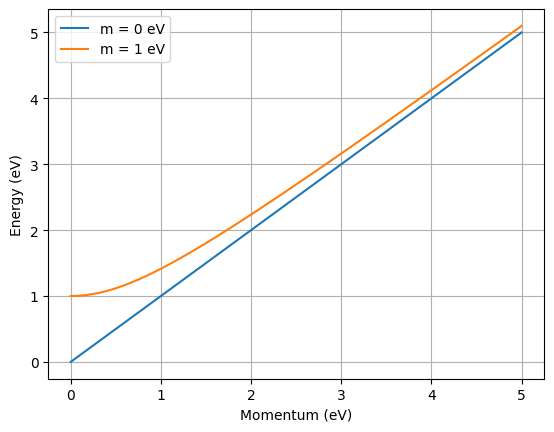

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Momentum range (small values!)
p = np.linspace(0, 5, 1000)   # 0 to 5 eV

# Masses
m0 = 0      # 0 eV
m1 = 1      # 1 eV

# Energy calculations
E0 = np.sqrt(p**2 + m0**2)
E1 = np.sqrt(p**2 + m1**2)

# Plot
plt.plot(p, E0, label="m = 0 eV")
plt.plot(p, E1, label="m = 1 eV")

plt.xlabel("Momentum (eV)")
plt.ylabel("Energy (eV)")
plt.legend()
plt.grid()
plt.show()


In [10]:
import numpy as np

def model_spectrum(m2, qU_array, E0, A, B):
    delta = E0 - qU_array
    arg = delta**2 - m2
    
    # Set negative values to zero smoothly
    arg = np.clip(arg, 0, None)
    
    spectrum = A * delta * np.sqrt(arg) + B
    
    # Also zero out region where delta <= 0
    spectrum = np.where(delta > 0, spectrum, B)
    
    return spectrum


In [11]:
def expected_counts(qU_array, E0, m2, A, B, t):
    rates = np.array([integrated_rate(qU, E0, m2) for qU in qU_array])
    return t * (A * rates + B)


In [12]:
def generate_data(lambda_array):
    return np.random.poisson(lambda_array)


In [13]:
from scipy.special import gammaln

def log_likelihood(m2, qU_array, data, E0, A, B, t):
    lambda_array = expected_counts(qU_array, E0, m2, A, B, t)
    return np.sum(data * np.log(lambda_array) - lambda_array - gammaln(data + 1))


In [14]:
# Define retarding potentials
qU_array = np.linspace(E0-3, E0, 2000)

# True parameters
E0 = 18600
A = 1e-9
B = 0
t = 1000

# Generate fake data
true_m2 = 0
model_counts = model_spectrum(true_m2, qU_array, E0, A, B)
data = np.random.poisson(model_counts * t)


In [15]:
qU_array = np.linspace(E0-3, E0, 2000)

E0 = 18600
A = 1
B = 0
t = 1000


In [16]:
print(np.min(model_counts))
print(np.max(model_counts))

0.34577402500000004
0.346071609


In [17]:
true_m2 = 0
model_counts = model_spectrum(true_m2, qU_array, E0, A, B)

data = np.random.poisson(model_counts * t)


In [18]:
def log_likelihood(m2, qU_array, data, E0, A, B, t):
    model_counts = model_spectrum(m2, qU_array, E0, A, B) * t
    
    # Avoid log(0)
    model_counts = np.clip(model_counts, 1e-10, None)
    
    return np.sum(data * np.log(model_counts) - model_counts)


In [19]:
m2_values = np.linspace(-2, 4, 200)
ll_values = []

for m2 in m2_values:
    ll = log_likelihood(m2, qU_array, data, E0, A, B, t)
    ll_values.append(ll)

best_m2 = m2_values[np.argmax(ll_values)]

print("Best fit m^2 =", best_m2)


Best fit m^2 = -0.01005025125628145


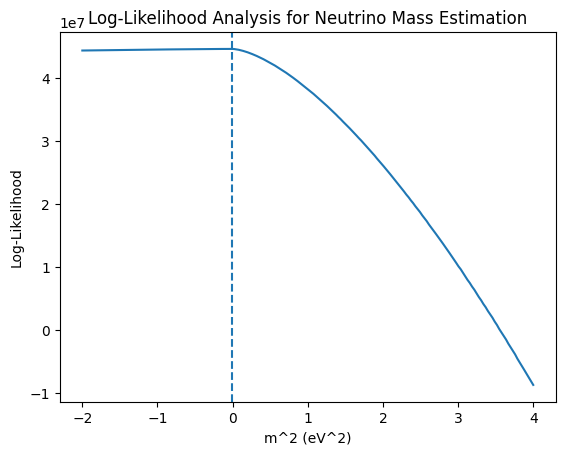

In [39]:
import matplotlib.pyplot as plt

plt.plot(m2_values, ll_values)
plt.axvline(best_m2, linestyle='--')
plt.xlabel("m^2 (eV^2)")
plt.ylabel("Log-Likelihood")
plt.title("Log-Likelihood Analysis for Neutrino Mass Estimation")
plt.savefig(
    "Fig_4_4_likelihood.png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()


In [21]:
def beta_spectrum(m2, qU_array, E0, A):
    delta = E0 - qU_array
    inside = delta**2 - m2

    spec = np.zeros_like(delta)
    mask = inside > 0

    spec[mask] = A * delta[mask] * np.sqrt(inside[mask])

    return spec

In [32]:
def sterile_model(m_light2, m4_2, U2, qU_array, E0, A, B):

    light_part = beta_spectrum(m_light2, qU_array, E0, A)
    heavy_part = beta_spectrum(m4_2, qU_array, E0, A)

    total = (1 - U2) * light_part + U2 * heavy_part

    return total + B

In [33]:
true_m_light2 = 0
true_m4_2 = 4.0        # 2 eV sterile neutrino
true_U2 = 0.03        # 5% mixing
A = 1e-9   # scaling (VERY important)
B = 0      # background
t = 100    # measurement time
model_counts = sterile_model(true_m_light2, true_m4_2, true_U2,
                              qU_array, E0, A, B)

data = np.random.poisson(model_counts * t)

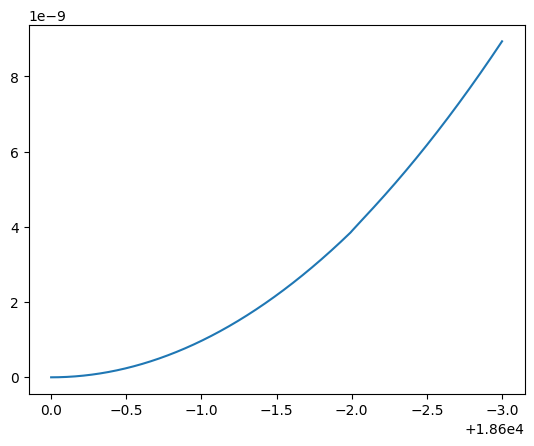

In [34]:
plt.plot(qU_array, model_counts)
plt.gca().invert_xaxis()
plt.show()

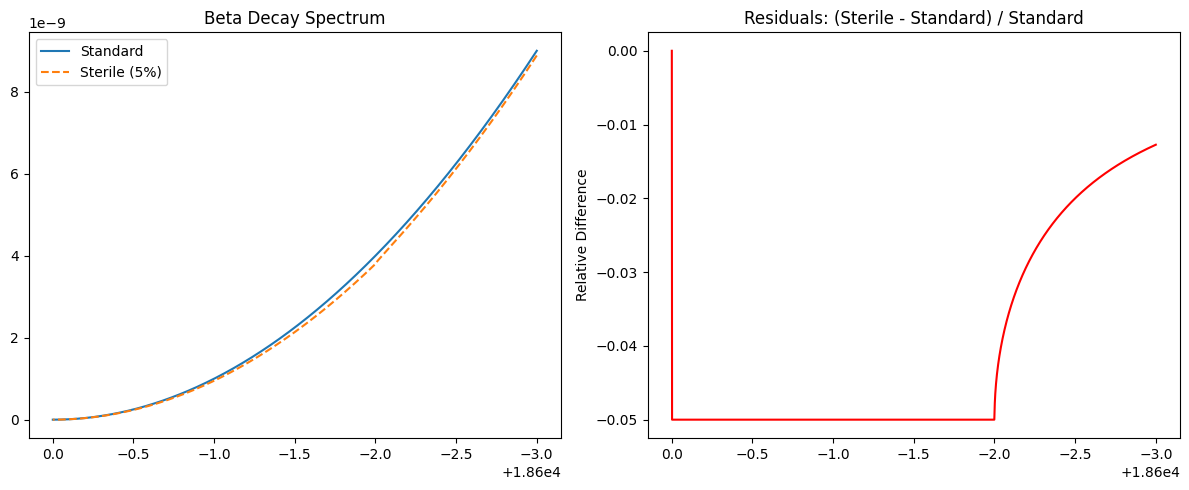

In [35]:
# 1. Ensure models are defined (Run your sterile_model function first!)
model_no_sterile = sterile_model(0, 4.0, 0.0, qU_array, E0, A, B)
model_with_sterile = sterile_model(0, 4.0, 0.05, qU_array, E0, A, B)

# 2. Calculate Residuals (This highlights the Kink)
# We add a tiny epsilon (1e-20) to avoid dividing by zero at the endpoint
residual = (model_with_sterile - model_no_sterile) / (model_no_sterile + 1e-20)

# 3. Plotting
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Left: Full Spectrum
ax[0].plot(qU_array, model_no_sterile, label="Standard")
ax[0].plot(qU_array, model_with_sterile, '--', label="Sterile (5%)")
ax[0].set_title("Beta Decay Spectrum")
ax[0].invert_xaxis()
ax[0].legend()

# Right: Residuals (The "Kink" Detector)
ax[1].plot(qU_array, residual, color='red')
ax[1].set_title("Residuals: (Sterile - Standard) / Standard")
ax[1].set_ylabel("Relative Difference")
ax[1].invert_xaxis()

# ZOOM in on the endpoint where E is near E0 - m4
# Adjust these limits based on your E0 and m4
# ax[1].set_xlim(E0 + 10, E0 - 50) 

plt.tight_layout()
plt.savefig(
    "Fig_4_1_Endpoint_Zoom.png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()

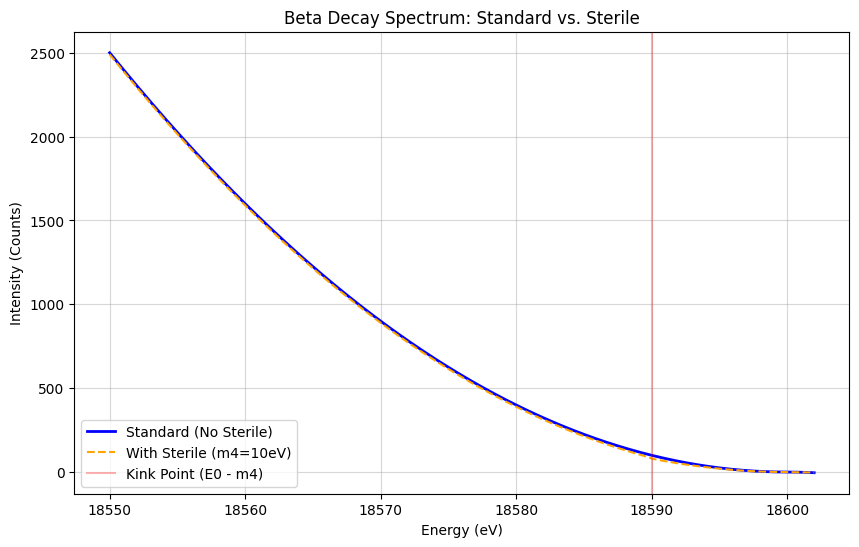

In [28]:
import matplotlib.pyplot as plt

# 1. Wider range: Look 50 eV below the endpoint to see the curve shape
E0 = 18600
qU_wide = np.linspace(E0 - 50, E0 + 2, 500) 

# 2. Calculate both models
# Standard model (m=0)
model_no_sterile = sterile_model(0, 0, 0.0, qU_wide, E0, 1, 0)

# Sterile model (m4=10eV, mixing=0.2 for clear visibility)
model_with_sterile = sterile_model(0, 100.0, 0.2, qU_wide, E0, 1, 0)

# 3. Plotting
plt.figure(figsize=(10, 6))

plt.plot(qU_wide, model_no_sterile, label="Standard (No Sterile)", color='blue', lw=2)
plt.plot(qU_wide, model_with_sterile, label="With Sterile (m4=10eV)", color='orange', linestyle='--')

# Mark the Kink
plt.axvline(E0 - 10, color='red', alpha=0.3, label="Kink Point (E0 - m4)")

plt.title("Beta Decay Spectrum: Standard vs. Sterile")
plt.xlabel("Energy (eV)")
plt.ylabel("Intensity (Counts)")
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend()
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_4836\2326782013.py:11: RuntimeWarning: invalid value encountered in sqrt
  return np.where(arg > 0, delta * np.sqrt(arg), 0)


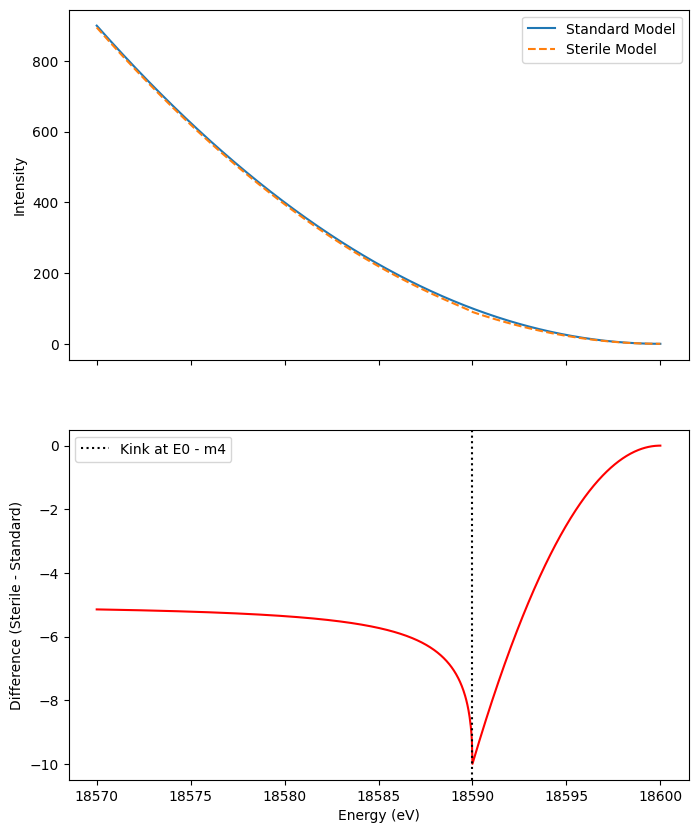

In [45]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define models with a clear sterile mass
E0 = 18600
qU = np.linspace(E0 - 30, E0, 1000)

def get_spec(m_sq, qU, E0):
    delta = E0 - qU
    arg = delta**2 - m_sq
    return np.where(arg > 0, delta * np.sqrt(arg), 0)

# Standard vs Sterile (Mass = 10eV, Mixing = 0.1)
std_model = get_spec(0, qU, E0)
sterile_model = 0.9 * get_spec(0, qU, E0) + 0.1 * get_spec(100, qU, E0)

# 2. Differentiate using a Residual Plot
residual = sterile_model - std_model

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 10), sharex=True)

ax1.plot(qU, std_model, label="Standard Model")
ax1.plot(qU, sterile_model, '--', label="Sterile Model")
ax1.set_ylabel("Intensity")
ax1.legend()

ax2.plot(qU, residual, color='red')
ax2.axvline(E0 - 10, color='black', linestyle=':', label="Kink at E0 - m4")
ax2.set_ylabel("Difference (Sterile - Standard)")
ax2.set_xlabel("Energy (eV)")
ax2.legend()
plt.savefig(
    "Fig_4_3_residual_plot.png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()

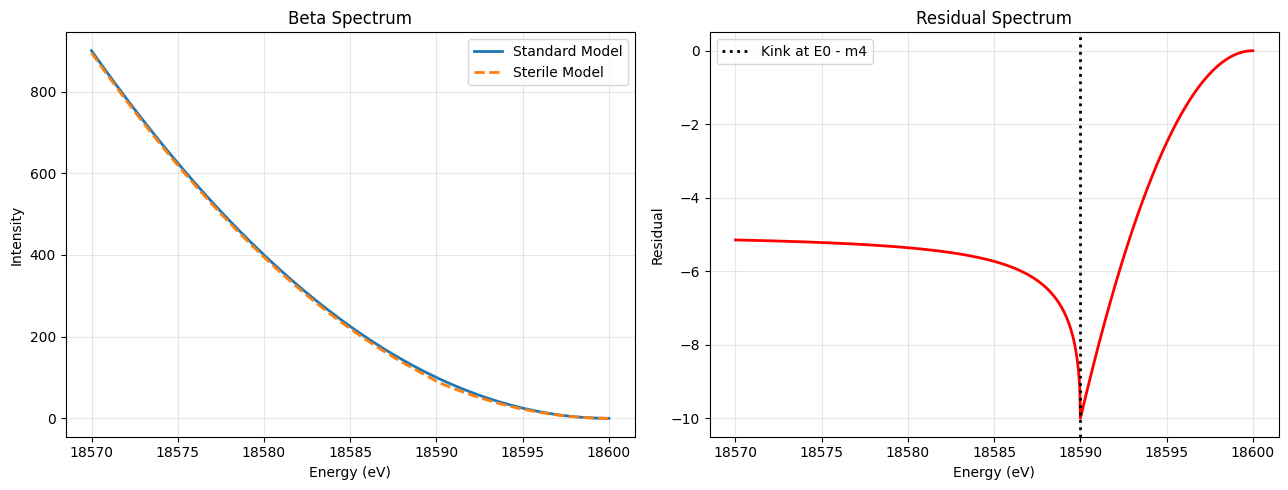

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# PARAMETERS
# =====================================================

E0 = 18600

qU = np.linspace(E0 - 30, E0, 1000)

# =====================================================
# MODEL
# =====================================================

def get_spec(m_sq, qU, E0):

    delta = E0 - qU

    arg = delta**2 - m_sq

    arg = np.clip(arg, 0, None)

    return delta * np.sqrt(arg)

# =====================================================
# STANDARD + STERILE MODELS
# =====================================================

std_model = get_spec(0, qU, E0)

sterile_model = (
    0.9 * get_spec(0, qU, E0)
    +
    0.1 * get_spec(100, qU, E0)
)

# =====================================================
# RESIDUAL
# =====================================================

residual = sterile_model - std_model

# =====================================================
# SIDE-BY-SIDE FIGURE
# =====================================================

fig, (ax1, ax2) = plt.subplots(
    1,
    2,
    figsize=(13,5)
)

# =====================================================
# LEFT PANEL
# =====================================================

ax1.plot(
    qU,
    std_model,
    lw=2,
    label="Standard Model"
)

ax1.plot(
    qU,
    sterile_model,
    '--',
    lw=2,
    label="Sterile Model"
)

ax1.set_xlabel("Energy (eV)")

ax1.set_ylabel("Intensity")

ax1.set_title("Beta Spectrum")

ax1.legend()

ax1.grid(True, alpha=0.3)

# =====================================================
# RIGHT PANEL
# =====================================================

ax2.plot(
    qU,
    residual,
    color='red',
    lw=2
)

ax2.axvline(
    E0 - 10,
    color='black',
    linestyle=':',
    lw=2,
    label="Kink at E0 - m4"
)

ax2.set_xlabel("Energy (eV)")

ax2.set_ylabel("Residual")

ax2.set_title("Residual Spectrum")

ax2.legend()

ax2.grid(True, alpha=0.3)

# =====================================================
# SAVE
# =====================================================

plt.tight_layout()

plt.savefig(
    "Fig_4_3_side_by_side.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

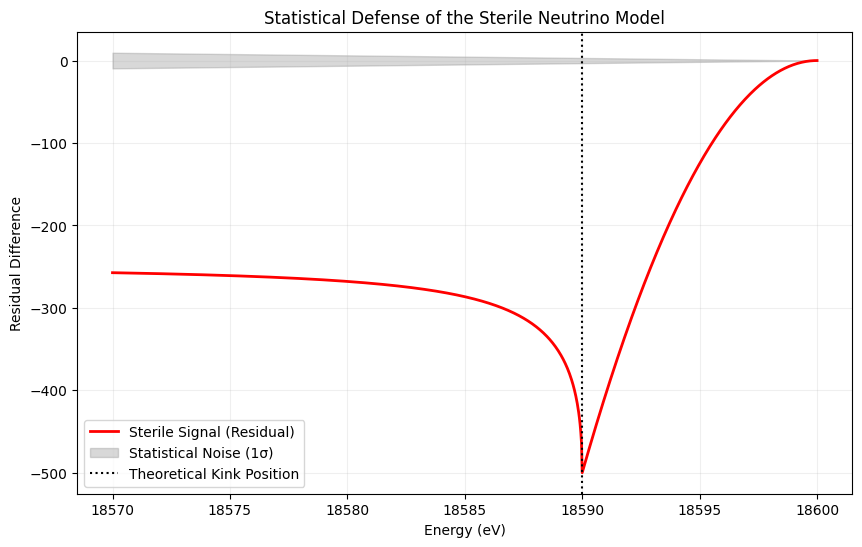

In [46]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Setup (using your parameters)
E0 = 18600
qU = np.linspace(E0 - 30, E0, 1000)
t = 1000  # exposure time
A = 100   # amplitude (increased for better statistics)

def get_spec(m_sq, qU, E0):
    delta = E0 - qU
    arg = delta**2 - m_sq

    arg = np.clip(arg, 0, None)
    
    return np.where(arg > 0, A * delta * np.sqrt(arg), 0)

# 2. Define Models
std_model = get_spec(0, qU, E0)
sterile_model = 0.95 * get_spec(0, qU, E0) + 0.05 * get_spec(100, qU, E0)

# 3. Calculate "Noise" (Statistical Uncertainty)
# Standard deviation of Poisson is sqrt(N). We normalize it for the residual plot.
sigma = np.sqrt(std_model * t) / t 
residual = sterile_model - std_model

# 4. Plotting
plt.figure(figsize=(10, 6))

# The "Kink" line
plt.plot(qU, residual, color='red', label='Sterile Signal (Residual)', lw=2)

# The Error Band (Gray Shaded Area)
plt.fill_between(qU, -sigma, sigma, color='gray', alpha=0.3, label='Statistical Noise (1σ)')

plt.axvline(E0 - 10, color='black', linestyle=':', label="Theoretical Kink Position")
plt.title("Statistical Defense of the Sterile Neutrino Model")
plt.xlabel("Energy (eV)")
plt.ylabel("Residual Difference")
plt.legend()
plt.grid(True, alpha=0.2)
plt.savefig(
    "Fig_4_6_residual_plot_statistical defence.png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_4836\908673920.py:14: RuntimeWarning: invalid value encountered in sqrt
  return np.where(arg > 0, A * delta * np.sqrt(arg), 0)


DEFENSE METRICS:
Chi-Square/DOF: 4855.23
Significance: inf sigma


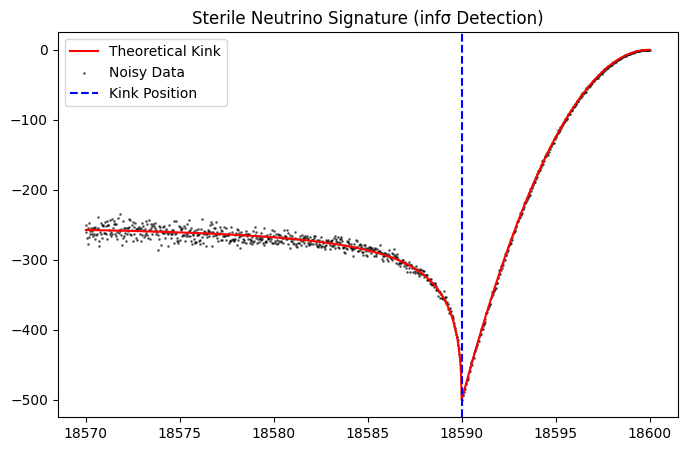

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# 1. PARAMETERS
E0 = 18600
qU = np.linspace(E0 - 30, E0, 1000)
t = 1000
A = 100

def get_spec(m_sq, qU, E0):
    delta = E0 - qU
    arg = delta**2 - m_sq
    return np.where(arg > 0, A * delta * np.sqrt(arg), 0)

# 2. GENERATE MODELS
# Standard Model (Null Hypothesis)
model_null = get_spec(0, qU, E0) * t

# Sterile Model (The "True" Physics we are testing for)
# m4 = 10eV (m_sq = 100), mixing = 0.05
model_sterile = (0.95 * get_spec(0, qU, E0) + 0.05 * get_spec(100, qU, E0)) * t

# 3. GENERATE SYNTHETIC DATA (The "Observation")
np.random.seed(42)
data = np.random.poisson(model_sterile) # This creates the 'data' variable

# 4. CHI-SQUARE CALCULATION
mask = model_null > 0
chi_sq = np.sum(((data[mask] - model_null[mask])**2) / model_null[mask])
dof = np.sum(mask)
p_val = 1 - stats.chi2.cdf(chi_sq, dof)
sigma = stats.norm.ppf(1 - p_val/2)

print(f"DEFENSE METRICS:")
print(f"Chi-Square/DOF: {chi_sq/dof:.2f}")
print(f"Significance: {sigma:.2f} sigma")

# 5. VISUAL PROOF
plt.figure(figsize=(8, 5))
plt.plot(qU, (model_sterile - model_null)/t, color='red', label='Theoretical Kink')
plt.scatter(qU, (data - model_null)/t, s=1, color='black', alpha=0.5, label='Noisy Data')
plt.axvline(E0 - 10, ls='--', color='blue', label='Kink Position')
plt.legend()
plt.title(f"Sterile Neutrino Signature ({sigma:.1f}σ Detection)")
plt.show()

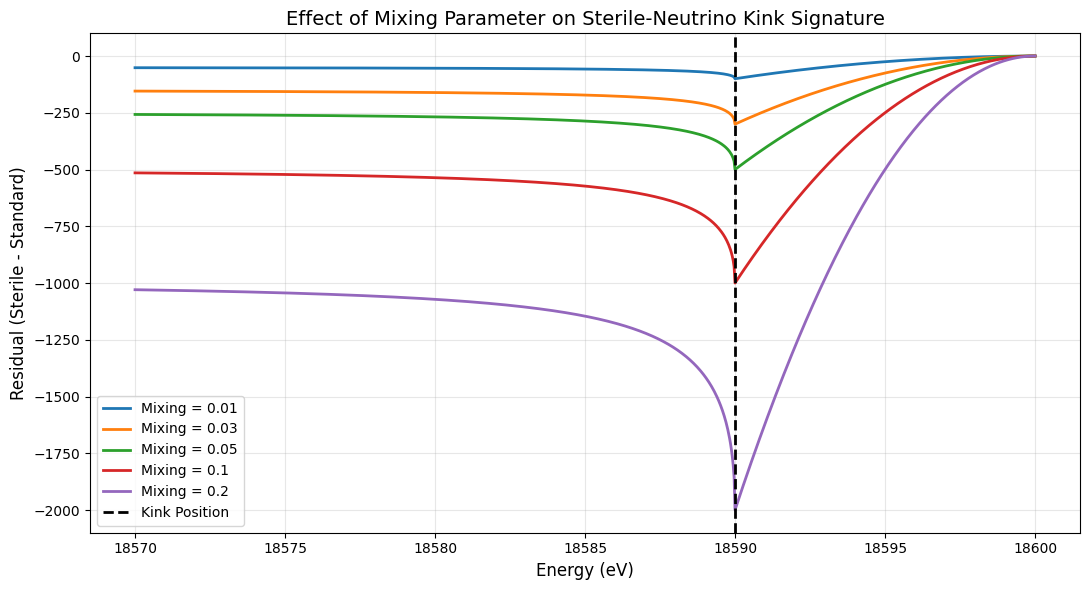

In [44]:
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# PARAMETERS
# =====================================================

E0 = 18600              # Endpoint energy (eV)

qU = np.linspace(E0 - 30, E0, 1000)

A = 100                 # Amplitude

m4 = 10                 # Sterile neutrino mass (eV)

m4_sq = m4**2

# =====================================================
# BETA SPECTRUM MODEL
# =====================================================

def get_spec(m_sq, qU, E0):

    delta = E0 - qU

    arg = delta**2 - m_sq

    # Prevent negative values inside sqrt
    arg = np.clip(arg, 0, None)

    return np.where(
        arg > 0,
        A * delta * np.sqrt(arg),
        0
    )

# =====================================================
# STANDARD MODEL
# =====================================================

std_model = get_spec(0, qU, E0)

# =====================================================
# MIXING PARAMETERS
# =====================================================

mixings = [
    0.01,
    0.03,
    0.05,
    0.10,
    0.20
]

# =====================================================
# PLOTTING
# =====================================================

plt.figure(figsize=(11,6))

for mixing in mixings:

    # Sterile neutrino model
    sterile_model = (
        (1 - mixing) * get_spec(0, qU, E0)
        +
        mixing * get_spec(m4_sq, qU, E0)
    )

    # Residual
    residual = sterile_model - std_model

    # Plot
    plt.plot(
        qU,
        residual,
        lw=2,
        label=f"Mixing = {mixing}"
    )

# =====================================================
# THEORETICAL KINK POSITION
# =====================================================

plt.axvline(
    E0 - m4,
    color='black',
    linestyle='--',
    lw=2,
    label='Kink Position'
)

# =====================================================
# LABELS
# =====================================================

plt.title(
    "Effect of Mixing Parameter on Sterile-Neutrino Kink Signature",
    fontsize=14
)

plt.xlabel(
    "Energy (eV)",
    fontsize=12
)

plt.ylabel(
    "Residual (Sterile - Standard)",
    fontsize=12
)

plt.grid(True, alpha=0.3)

plt.legend()

plt.tight_layout()
plt.savefig(
    "Fig_4_5_2_efect of mixing parameter on residual plot.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

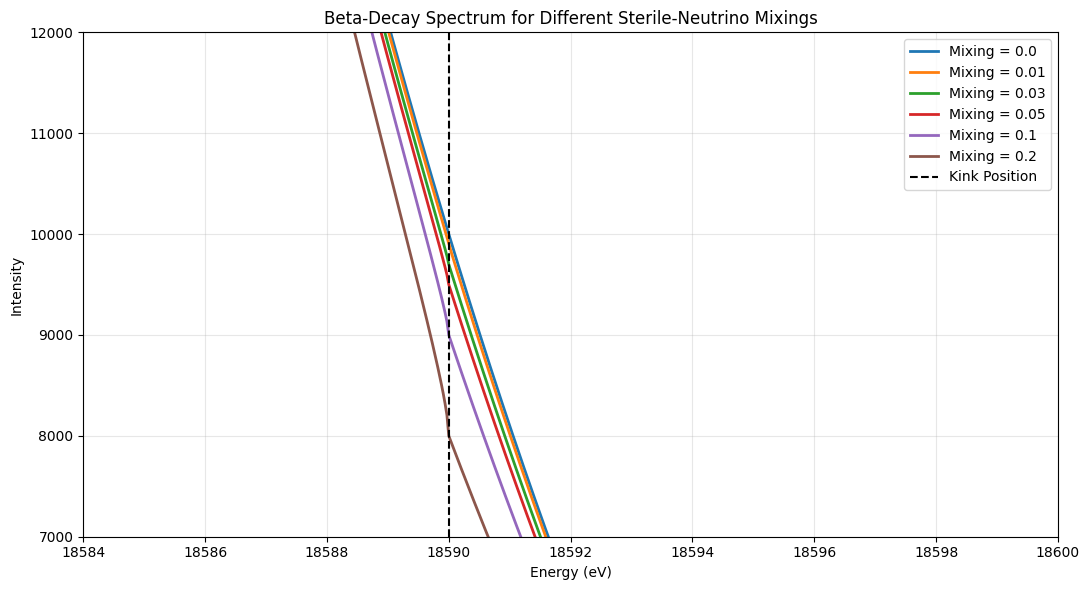

In [43]:
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# PARAMETERS
# =====================================================

E0 = 18600

qU = np.linspace(E0 - 30, E0, 1000)

A = 100

m4 = 10

m4_sq = m4**2

# =====================================================
# MODEL
# =====================================================

def get_spec(m_sq, qU, E0):

    delta = E0 - qU

    arg = delta**2 - m_sq

    arg = np.clip(arg, 0, None)

    return np.where(
        arg > 0,
        A * delta * np.sqrt(arg),
        0
    )

# =====================================================
# STANDARD MODEL
# =====================================================

std_model = get_spec(0, qU, E0)

# =====================================================
# MIXINGS
# =====================================================

mixings = [
    0.00,
    0.01,
    0.03,
    0.05,
    0.10,
    0.20
]

# =====================================================
# PLOT
# =====================================================

plt.figure(figsize=(11,6))

for mixing in mixings:

    sterile_model = (
        (1 - mixing) * get_spec(0, qU, E0)
        +
        mixing * get_spec(m4_sq, qU, E0)
    )

    plt.plot(
        qU,
        sterile_model,
        lw=2,
        label=f"Mixing = {mixing}"
    )

# =====================================================
# KINK POSITION
# =====================================================

plt.axvline(
    E0 - m4,
    color='black',
    linestyle='--',
    label='Kink Position'
)
plt.xlim(18584, 18600)
plt.ylim(7000, 12000)
# =====================================================
# LABELS
# =====================================================

plt.title(
    "Beta-Decay Spectrum for Different Sterile-Neutrino Mixings"
)

plt.xlabel("Energy (eV)")

plt.ylabel("Intensity")

plt.grid(True, alpha=0.3)

plt.legend()

plt.tight_layout()
plt.savefig(
    "Fig_4_5_1_beta decay spectrum for diff mixing.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()